### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from hydra import compose, initialize
from pathlib import Path
from omegaconf import OmegaConf

initialize(config_path="../config", version_base="1.3")
cfg = compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

sys.path.insert(0, str(cfg.paths.project_root))

paths:
  project_root: /home/p84400019/projects/consciousness-llms/IT-LLMs/
  model_path: ${model.company}/${model.model_family}/${model.model_size}/${model.it}/
  activation_method: ${time_series.node_type}/${time_series.node_activation}/${time_series.projection_method}/
  phyid_method: ${paths.activation_method}phyid_tau-${phyid.tau}/phyid_kind-${phyid.kind}/phyid_redundancy-${phyid.redundancy}/
  data_dir: ${paths.project_root}data/${paths.model_path}${generation.name}/
  data_activations_dir: ${paths.data_dir}activations/
  data_activations_file: ${paths.data_activations_dir}multi_prompt_activations.pkl
  data_phyid_dir: ${paths.data_dir}phyid/${paths.phyid_method}
  data_phyid_file: ${paths.data_phyid_dir}multi_prompt_phyid.pkl
  data_phyid_file_data_array: ${paths.data_phyid_dir}multi_prompt_phyid.nc
  plot_dir: ${paths.project_root}plots/${paths.model_path}${generation.name}/
  plot_time_series_dir: ${paths.plot_dir}time_series/${paths.activation_method}
  plot_phyid_dir: ${path

### Time Series Loading

In [2]:
from src.activation_recorder import MultiPromptActivations

data_activations_file = cfg.paths.data_activations_file
activations = MultiPromptActivations.load(file_path=data_activations_file)

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MultiPromptActivations successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/activations/multi_prompt_activations.pkl'.


In [3]:
from src.time_series_activations import MultiPromptTimeSeries

time_series = MultiPromptTimeSeries.from_activations(
    activations, 
    node_type=cfg.time_series.node_type,
    node_activation=cfg.time_series.node_activation,
    projection_method=cfg.time_series.projection_method, 
    exclude_shared_expert_moe=cfg.time_series.exclude_shared_expert_moe, 
)
time_series.plot(token_x=True, ticks_all_layers=True, plot_dir=cfg.paths.plot_time_series_dir)

Prompt 0 has 128 generated tokens: ['\n', '\n', '##', ' Answer', ':', '\n', 'The', ' adaptations', ' that', ' humans', ' might', ' develop', ' in', ' a', ' future', ' where', ' they', ' live', ' underwater', ' include', ' g', 'ills', ',', ' web', 'bed', ' fingers', ' and', ' toes', ',', ' and', ' the', ' ability', ' to', ' breathe', ' underwater', '.', '\n', '\n', '##', ' Ex', 'planation', ':', '\n', 'Hum', 'ans', ' would', ' need', ' to', ' develop', ' g', 'ills', ' in', ' order', ' to', ' breathe', ' underwater', '.', ' G', 'ills', ' are', ' specialized', ' organs', ' that', ' allow', ' aquatic', ' animals', ' to', ' extract', ' oxygen', ' from', ' water', '.', ' Humans', ' would', ' need', ' to', ' develop', ' g', 'ills', ' in', ' order', ' to', ' breathe', ' underwater', ',', ' and', ' this', ' would', ' likely', ' involve', ' the', ' development', ' of', ' a', ' new', ' organ', ' or', ' the', ' modification', ' of', ' existing', ' organs', '.', '\n', 'In', ' addition', ' to', ' g'

### PhyID Decomposition

In [2]:
from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries
compute_phyid = False
data_phyid_file = cfg.paths.data_phyid_file

if compute_phyid:
    phyid_comp = MultiPromptPhyID.from_time_series(
        time_series,
        cfg.phyid.tau,
        cfg.phyid.kind,
        cfg.phyid.redundancy
    ) 
    phyid_comp.save(file_path=data_phyid_file)

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
single_prompt = True

print(f"Loading phyid from {data_phyid_file}")
phyid = MultiPromptPhyID.load(file_path=data_phyid_file)

if single_prompt:
    # phyid.compute_extra_atoms()
    phyid = phyid.get_prompt(prompt_index=0)  # Get the first prompt's phyid
    print("Building data array for phyid")
    phyid.build_data_array()
    print("Saving data array for phyid")
    phyid.save_data_array(file_path=cfg.paths.data_phyid_file_data_array)
else:
    print("Computing average prompt phyid")
    phyid.build_data_array()
    print("Computing average prompt phyid")
    phyid = phyid.compute_average_prompt_phyid()


Loading phyid from /home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/multi_prompt_phyid.pkl
MultiPromptPhyID successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/deepseek/deepseek-v2/16B-A2B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/multi_prompt_phyid.pkl'.
Building data array for phyid
Saving data array for phyid


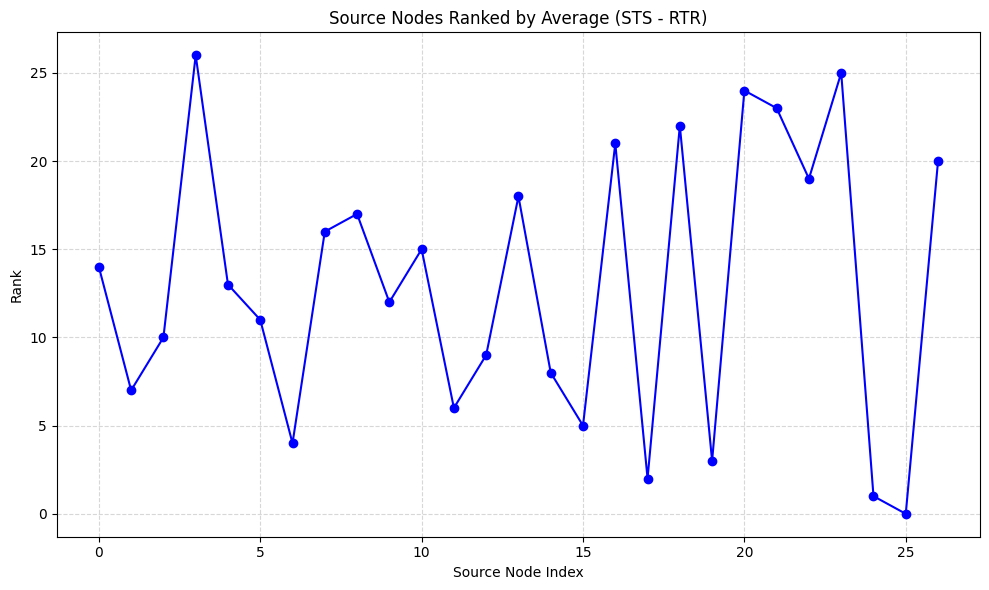

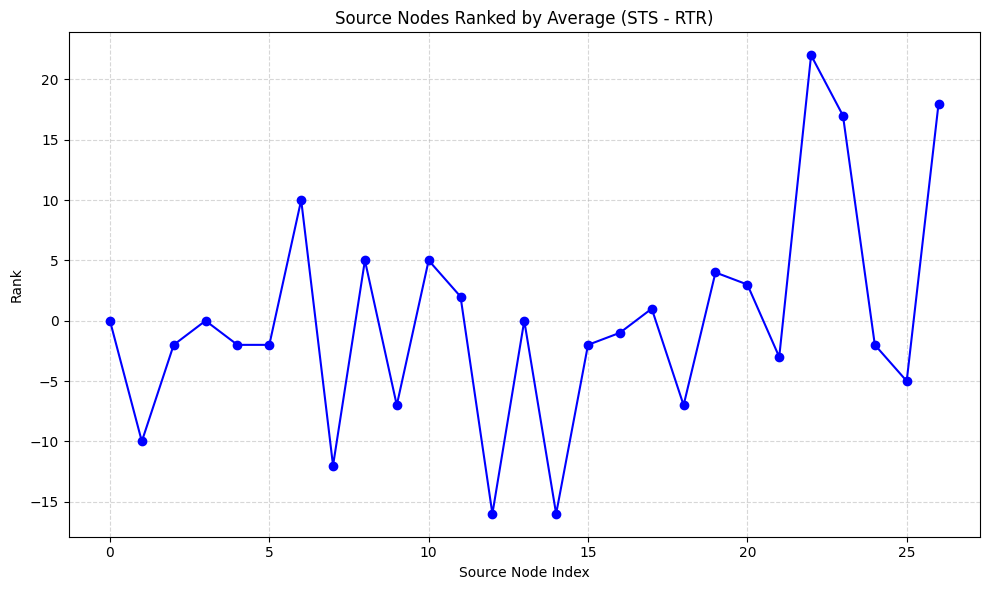

In [4]:
phyid.plot_syn_minus_red_rank("syn_minus_red_rank")
phyid.syn_rank_minus_red_rank
phyid.plot_syn_minus_red_rank("syn_rank_minus_red_rank")

In [ ]:
phyid = MultiPromptPhyID.load_from_data_array(file_path=cfg.paths.data_phyid_file_data_array)
phyid = phyid.compute_average_prompt_phyid()

In [1]:
plot_dir = cfg.paths.plot_phyid_dir
# plot_dir = None
phyid.node_heatmap(atom='sts', plot_dir=plot_dir)
phyid.plot_mean_along('sts', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('rtr', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('mutual_information', varying_dim='source_layer', plot_dir=plot_dir)

NameError: name 'cfg' is not defined

### Graph Theoretical Analysis

In [ ]:
from src.graph_theoretical_analysis import PromptGraphTheoreticalAnalysis

graph_theoretical = PromptGraphTheoreticalAnalysis.from_phyid_data(prompt_phyid=phyid)

In [ ]:
# graph_theoretical.plot_atom_graph(atom='sts')
sge = graph_theoretical.global_efficiency(atom='sts')
smo = graph_theoretical.modularity(atom='sts')
rge = graph_theoretical.global_efficiency(atom='rtr')
rmo = graph_theoretical.modularity(atom='rtr')
print(f"STS Global Efficiency: {sge}, STS Modularity: {smo}")
print(f"RTR Global Efficiency: {rge}, RTR Modularity: {rmo}")

STS Global Efficiency: 0.06254600312746986, STS Modularity: 0.1585022786660078
RTR Global Efficiency: 0.012671264505256527, RTR Modularity: 0.14871445759811913
